In [97]:
%matplotlib inline
import bioread
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle
import pingouin as pg
from scipy.special import logit
import statsmodels.formula.api as smf

In [98]:
def fixPB12(master_df):
    # Fix PB12 with values from B12-partie_2
    # Define the segments to be replaced
    target_segments = ['stress2_MIST', 'nf2_2D']
    # Extract the "Source" data (from PB12-partie_2)
    # We make a .copy() to avoid modifying the original dataframe accidentally
    source_data = master_df[
        (master_df['Participant'] == 'PB12-partie_2') &
        (master_df['Segment'].isin(target_segments))].copy()
    # Change the ID in the source data to match the "Target" (PB12)
    source_data['Participant'] = 'PB12'
    # Remove the "Old/Corrupt" segments from the target (PB12)
    # This prevents the 'Duplicate entries' error in your delta function
    master_df = master_df.drop(
        master_df[
            (master_df['Participant'] == 'PB12') &
            (master_df['Segment'].isin(target_segments))
        ].index
    )
    # Append the "New" data from PB12-partie_2 into the master dataframe
    master_df = pd.concat([master_df, source_data], ignore_index=True)
    ## Optional: Remove the temporary 'PB12-partie_2' rows if you no longer need them
    master_df = master_df[master_df['Participant'] != 'PB12-partie_2']
    #print("Final segments for PB12:")
    #print(master_df.query("Participant == 'PB12'")['Segment'].unique())
    #print('PB12-partie_2 in function')
    #print(master_df.query("Participant == 'PB12-partie_2'")['Segment'].unique())
    return master_df

In [99]:
def produce_normalized_metrics(master_df):
    log_metrics = ['EDA_Tonic_Mean', 'EDA_Tonic_SD', 'SCR_Peaks_Amplitude_Mean']
    for metric in log_metrics:
        if metric in master_df.columns:
            # Create a dataframe of just baselines
            baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')[metric].mean()
            # Map those baselines back to the main dataframe
            master_df['Participant_Baseline_' + metric] = master_df['Participant'].map(baselines)
            # Apply ln(1+x) to normalize the distribution of EDA/SCR
            master_df[metric] = np.log1p(master_df[metric]) - np.log1p(master_df['Participant_Baseline_' + metric])
        master_df[metric] = np.log1p(master_df[metric])

    # Get average baseline per participant for SCR_Frequency_PerMin
    scr_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['SCR_Frequency_PerMin'].mean()
    # Map those baselines back to the main dataframe
    master_df['SCR_Freq_Delta'] = np.sqrt(master_df['SCR_Frequency_PerMin']) - np.sqrt(master_df['Participant'].map(scr_baselines))
    master_df['SCR_Freq_Norm'] = np.sqrt(master_df['SCR_Frequency_PerMin'])

    sym_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['EDA_SympatheticN'].mean()
    # Map those baselines back to the main dataframe
    #master_df['EDA_Sympathetic_Delta'] = np.log(master_df['EDA_SympatheticN'].clip(0.001, 0.999)) - np.log(master_df['Participant'].map(sym_baselines).clip(0.001, 0.999))
    master_df['EDA_Sympathetic_Delta'] = (np.log(master_df['EDA_SympatheticN']) - np.log(master_df['Participant'].map(sym_baselines)))*100
    master_df['EDA_Sympathetic_Norm'] = np.log(master_df['EDA_SympatheticN'] + 1e-6)*100
    #master_df['EDA_Sympathetic_Norm'] = np.log1p(master_df['EDA_SympatheticN'])*100

    # Get average baseline per participant for ECG
    ecg_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['ECG_Rate_Mean'].mean()
    # Map and subtract to get the "BPM Change"
    master_df['ECG_Delta_over_baseline'] = master_df['ECG_Rate_Mean'] - master_df['Participant'].map(ecg_baselines)

    # Get average baseline per participant for HRV (RMSSD)
    hrv_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['HRV_RMSSD'].mean()
    # Map and subtract to get the "ms Change"
    # Negative values = Reduced regulation (higher stress) | Positive values = Increased relaxation
    master_df['HRV_Delta_over_baseline'] = master_df['HRV_RMSSD'] - master_df['Participant'].map(hrv_baselines)
    master_df['HRV_RMSSD_Delta'] = np.log(master_df['HRV_RMSSD']) - np.log(master_df['Participant'].map(hrv_baselines))
    master_df['HRV_RMSSD_Norm'] = np.log(master_df['HRV_RMSSD'] + 1e-6)
    #master_df['HRV_RMSSD_Norm'] = np.log1p(master_df['HRV_RMSSD']) 
    return master_df

In [100]:
def produce_deltas(master_df):
    # Define the metrics to calculate
    metrics = ["SCR_Freq_Norm", "EDA_Sympathetic_Norm", "HRV_RMSSD_Norm"]
    # Loop through each metric to create the reactivity scores
    for metric in metrics:
        # Filter for the specific segments to calculate the delta
        nf1_values = master_df[master_df['Segment'].str.contains('nf1')].set_index('Participant')[metric]
        nf2_values = master_df[master_df['Segment'].str.contains('nf2')].set_index('Participant')[metric]
        stress1_values = master_df[master_df['Segment'].str.contains('stress1')].set_index('Participant')[metric]
        stress2_values = master_df[master_df['Segment'].str.contains('stress2')].set_index('Participant')[metric]
        # Calculate the difference: Stress1 - Nf1
        diff_series1 = nf1_values - stress1_values
        diff_series2 = nf2_values - stress2_values
        # Create the new metric name (e.g., 'SCR_Freq_Norm_reactivity')
        diff_col_name = f"{metric}_delta"
        # Initialize the column with NaN
        master_df[diff_col_name] = np.nan
        # Map the nf1 calculated differences to the 'nf1' rows
        mask1 = master_df['Segment'].str.contains('nf1')
        master_df.loc[mask1, diff_col_name] = master_df.loc[mask1, 'Participant'].map(diff_series1)
        # Map the nf2 calculated differences to the 'nf2' rows
        mask2 = master_df['Segment'].str.contains('nf2')
        master_df.loc[mask2, diff_col_name] = master_df.loc[mask2, 'Participant'].map(diff_series2)

    ## Check the result for the first participant's nf1 row
    #print(master_df[master_df['Segment'].str.contains('nf1')][['Participant', 'Segment'] + [f"{m}_delta" for m in metrics]].head())
    ## Check the result for the first participant's nf2 row
    #print(master_df[master_df['Segment'].str.contains('nf2')][['Participant', 'Segment'] + [f"{m}_delta" for m in metrics]].head())
    return master_df


In [101]:
def main():
    # Unpickling (deserializing) from a file
    with open('../dfmaster.pkl', 'rb') as f:
        master_df = pickle.load(f)

    master_df = fixPB12(master_df)
    #print('PB12-partie_2 in master')
    #print(master_df.query("Participant == 'PB12-partie_2'")['Segment'].unique())
    #print("Final segments for PB12:")
    #print(master_df.query("Participant == 'PB12'")['Segment'].unique())
    #print(master_df[master_df['Participant'] == 'PB12'].to_string())
    master_df = produce_normalized_metrics(master_df)
    master_df = produce_deltas(master_df)
    #analysis_of_deltas_with_groups(master_df)
    LMM_Condition_vrfirst_abbafirst_phase(master_df)
    #LMM_Condition_x_vrfirst_abbafirst_phase(master_df)
    return 0

In [102]:
def LMM_Condition_vrfirst_abbafirst_phase(master_df):
    import statsmodels.formula.api as smf
    clean_df = master_df.copy()
    clean_df['Condition'] = clean_df['Segment'].apply(lambda x: 'VR' if 'VR' in x else '2D')
    clean_df['Baseline'] = clean_df['Segment'].apply(lambda x: 'baseline' if 'baseline' in x else 'not_baseline')
    # Try to use linearly independent conditions
    # Identify participants who have at least one segment named 'nf1_VR'
    vr_first_participants = clean_df.loc[clean_df['Segment'] == 'nf1_VR', 'Participant'].unique()
    # Create the column: If the participant is in that list, mark all their rows as 'VRfirst'
    clean_df['vrfirst'] = clean_df['Participant'].apply(
        lambda x: 'VRfirst' if x in vr_first_participants else 'VRlast'
    )
    # Identify participants who have at least one segment named 'stress1_ABBA'
    abba_first_participants = clean_df.loc[clean_df['Segment'] == 'stress1_ABBA', 'Participant'].unique()
    # Create the column: If the participant is in that list, mark all their rows as 'ABBAfirst'
    clean_df['abbafirst'] = clean_df['Participant'].apply(
        lambda x: 'ABBAfirst' if x in abba_first_participants else 'ABBAlast'
    )
    # Define the conditions
    conditions = [
        clean_df['Segment'].str.contains('nf1', case=False, na=False),
        clean_df['Segment'].str.contains('nf2', case=False, na=False)
    ]
    # Define the corresponding values
    choices = ['phase1', 'phase2']
    # Create the column (default to 'other' if neither nf1 nor nf2 is found)
    clean_df['Phase'] = np.select(conditions, choices, default='other')

    # Define the conditions
    conditions = [
        clean_df['Segment'].str.contains('ABBA', case=False),
        clean_df['Segment'].str.contains('MIST', case=False)
    ]
    # Define the corresponding values
    choices = ['ABBA', 'MIST']
    # Create the column (default to 'other' if neither nf1 nor nf2 is found)
    clean_df['StressTask'] = np.select(conditions, choices, default='other')

    #clean_df = clean_df[clean_df['StressTask'] != 'other']
    #print(clean_df['StressTask'])
    #print("Unique values in StressTask:", clean_df['StressTask'].unique())
    #return
    #clean_df['StressTask'] = clean_df['Segment'].apply(
    #    lambda x: 'Stress' if 'stress' in x.lower() else 'Control'
    #)

    # Define the conditions
    conditions = [
        clean_df['Segment'].str.contains('stress', case=False),
        clean_df['Segment'].str.contains('baseline', case=False)
    ]
    # Define the corresponding values
    choices = ['Stress', 'Baseline']
    # Create the column (default to 'other' if neither nf1 nor nf2 is found)
    clean_df['SegmentType'] = np.select(conditions, choices, default='other')
    clean_df = clean_df[clean_df['SegmentType'] != 'other']
    #print(clean_df['SegmentType'])
    metrics = []
    pvalues = []
    #for metric, title in [ ("SCR_Freq_Norm_delta", "Normalized SCR Frequency delta"),
    #                      ("EDA_Sympathetic_Norm_delta", "Normalized EDA Sympathetic delta"),
    for metric, title in [ ("SCR_Freq_Delta", "Normalized SCR Frequency delta"),
                          ("EDA_Sympathetic_Delta", "Normalized EDA Sympathetic delta"),
                          #("EDA_Tonic_Mean", "EDA Tonic Mean"),
                          #("ECG_Delta_over_baseline", "ECG Delta over baseline"),
                          #("HRV_RMSSD_Norm_delta", "Normalized HRV RMSSD delta")]:
                          ("HRV_RMSSD_Delta", "Normalized HRV RMSSD delta")]:
        clean_df[metric] = pd.to_numeric(clean_df[metric], errors='coerce')
        clean_df = clean_df.dropna(subset=[metric]).reset_index(drop=True)
        #formula = metric + " ~ Condition + vrfirst + abbafirst + Phase + Baseline"
        formula = metric + " ~ SegmentType"
        #formula = metric + " ~ StressTask"
        #formula = metric + " ~ C(StressTask, Treatment(reference='ABBA'))"
        outliers_to_remove = []
        #if metric == "SCR_Freq_Norm_delta":
        #elif metric == "EDA_Sympathetic_Norm_delta":
        #elif metric == "HRV_RMSSD_Norm_delta":
        if metric == "SCR_Freq_Delta":
            outliers_to_remove = ['PB13']
        elif metric == "EDA_Sympathetic_Delta":
            #    #outliers_to_remove = ['PB23', 'PB12']
            #    outliers_to_remove = ['PB21']
            #outliers_to_remove = ['PB7']
            pass
        elif metric == "HRV_RMSSD_Delta":
            #    outliers_to_remove = ['PB23', 'PB21', 'PB19']
            outliers_to_remove = ['PB21', 'PB14', 'PB25']
        df_cleaned_out = clean_df[~clean_df['Participant'].isin(outliers_to_remove)]
        result = LMM_runmodel(df_cleaned_out, formula, title)
        ## Try OLS since Group Var is 0
        #ols_model = smf.ols(formula, data=clean_df).fit()
        #print("--- OLS model for "+formula+" ---")
        #print(ols_model.summary())
        #print("\n")
        #metrics.append(metric)
        #pvalues.append(result.pvalues["Condition[T.VR]"])
        # Boxplot of (raw) metric
        #plot_raw_boxplot(clean_df, metric, title)

    #summary_df = get_fdr(metrics,pvalues)
    #print("--- FDR (Benjamini-Hochberg) for main metrics ---")
    #print(summary_df)
    #print("\n")

    #do_VIF_report(clean_df)

    # Calculate descriptive statistics for the key metrics
    ## Create the summary table
    #desc_table = clean_df.groupby(['vrfirst', 'Condition'])[metrics].agg(['mean', 'std']).round(3)
    ## Reset index for a cleaner look if exporting to CSV
    #desc_table.to_csv("Appendix_Descriptives_main_efffect_models_normalized.csv")
    #print("--- Descriptive statistics report for the key metrics (normalized) ---")
    #print(desc_table)
    #print("\n")

    #rawmetrics = ['SCR_Frequency_PerMin', 'Sympathetic_Percent', 'HRV_RMSSD']
    #desc_table = clean_df.groupby(['vrfirst', 'Condition'])[rawmetrics].agg(['mean', 'std']).round(3)
    ## Reset index for a cleaner look if exporting to CSV
    #desc_table.to_csv("Appendix_Descriptives_main_efffect_models.csv")
    #print("--- Descriptive statistics report for the key metrics (raw) ---")
    #print(desc_table)
    #print("\n")
    #print("(Sympathetic_Percent = EDA_SympatheticN * 100)")

In [103]:
def plot_raw_boxplot(df, outcome, title):
    import matplotlib.patches as mpatches

    plt.figure(figsize=(9, 6))
    sns.set_style("whitegrid")

    # Define your high-contrast colors
    color_2d = '#003f5c' # Navy
    color_vr = '#ff7c43' # Orange
    my_palette = {'2D': color_2d, 'VR': color_vr}

    # Boxplot - Explicitly define hue and palette
    ax = sns.boxplot(x='Condition', y=outcome, data=df,
                     hue='Condition',
                     palette=my_palette, legend=False,
                     width=0.4, showfliers=False, boxprops=dict(alpha=0.7))

    # Stripplot - legend=False to prevent duplicates
    sns.stripplot(x='Condition', y=outcome, data=df,
                  hue='Condition',
                  palette=my_palette, legend=False,
                  size=6, jitter=True, alpha=0.5, edgecolor='auto', linewidth=0.5)

    plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

    # FIX: Create Manual Legend Handles
    patch_2d = mpatches.Patch(color=color_2d, label='2D')
    patch_vr = mpatches.Patch(color=color_vr, label='VR')
    # Add the Legend using the manual handles
    plt.legend(handles=[patch_2d, patch_vr],
               title="Condition",
               bbox_to_anchor=(1.05, 1),
               loc='upper left',
               borderaxespad=0.)

    # Labels and Title
    plt.title(f'Boxplot of the individual distribution of\n{title}', fontsize=14, pad=15)
    plt.ylabel(f'{title}')
    plt.xlabel('Condition')

    # Optional: Add the raw p-value from your model as an annotation
    # Based on your SCR model results
    #plt.text(0.5, df[outcome].max(), 'p = 0.022*',
    #         ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'Raw_Boxplot_{outcome}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [104]:
def calculate_fdr_for_model(result):
    from statsmodels.stats.multitest import multipletests
    # Get all p-values except the Intercept
    p_series = result.pvalues.drop('Intercept')
    # Apply Benjamini-Hochberg
    reject, p_adj, _, _ = multipletests(p_series, method='fdr_bh')
    # Create a clean results table
    fdr_df = pd.DataFrame({
        'Predictor': p_series.index,
        'Raw_P': p_series.values,
        'FDR_Adjusted_P': p_adj,
        'Significant': reject
    })
    return fdr_df

In [105]:
def get_fdr(metrics,pvalues):
    from statsmodels.stats.multitest import multipletests
    # Create a summary dataframe
    summary_df = pd.DataFrame({
        'Metric': metrics,
        'Raw_P': pvalues
    })
    # Apply FDR (Benjamini-Hochberg)
    # returns: (reject_array, corrected_p_array, alphacSidak, alphacBonf)
    results = multipletests(summary_df['Raw_P'], method='fdr_bh')
    summary_df['Adjusted_P'] = results[1]
    summary_df['Significant'] = results[0]
    return(summary_df)

In [106]:
def get_all_contrasts(result):
    fe_names = result.model.exog_names
    contrast_results = []

    for name in fe_names:
        # Create the 2D contrast matrix (1 x k_fe)
        contrast_matrix = np.zeros((1, len(fe_names)))
        target_idx = fe_names.index(name)
        contrast_matrix[0, target_idx] = 1

        # Run the test
        t_test_res = result.t_test(contrast_matrix)

        # Calculate Effect Sizes:
        z_val = t_test_res.tvalue[0][0]
        n_obs = result.nobs

        # Calculate r (correlation coefficient effect size)
        r_effect = np.abs(z_val) / np.sqrt(z_val**2 + n_obs)

        # Calculate Cohen's d equivalent
        d_effect = (2 * z_val) / np.sqrt(n_obs)

        # Extract statistics
        # result.t_test returns a ContrastResults object
        contrast_results.append({
            "Effect": name,
            "Coefficient": t_test_res.effect[0],
            "Std.Err": t_test_res.sd[0],
            "z-stat": t_test_res.tvalue[0][0], # statsmodels calls it tvalue even for z
            "p-value": t_test_res.pvalue,
            "r_effect": r_effect,
            "d_effect": d_effect
        })
    return pd.DataFrame(contrast_results)

In [107]:
def get_standardized_beta(clean_df, modelresult, outcome):
    # Manual calculation for Condition[T.VR]
    b = modelresult.params['Condition[T.VR]']
    sd_y = clean_df['Sympathetic_Delta'].std()
    # For a dummy variable (0 or 1), SD is sqrt(p * (1-p))
    # Or simply take the std of the encoded column
    condition_numeric = (clean_df['Condition'] == 'VR').astype(int)
    sd_x = condition_numeric.std()
    std_beta = b * (sd_x / sd_y)
    return std_beta

In [108]:
def LMM_runmodel(clean_df, formula, title):
    # 'Condition' is your categorical variable
    outcome = formula.split()[0]
    #model = smf.mixedlm("EDA_Tonic_Mean ~ Condition + Other_Predictors",
    model = smf.mixedlm(formula,
                        data=clean_df,
                        groups=clean_df["Participant"])
    result = model.fit()
    print("=== Statsmodels Linear Mixed Model " + formula + " ===")
    print(result.summary())
    fdr_table = calculate_fdr_for_model(result)
    print("--- FDR (Benjamini-Hochberg) for model " + formula + " ---")
    print(fdr_table)
    print("\n")
    m_r2, c_r2 = calculate_r2_mixed(result)
    print("--- R2 Report "+title+" ---")
    print(f"Marginal R2 (Fixed effects): {m_r2:.3f}")
    print(f"Conditional R2 (Total model): {c_r2:.3f}")
    print("\n")
    print("--- Estimated Marginal Means ("+title+") ---")
    if "Condition * vrfirst" in formula: 
        emms = calculate_emmeans(result) # Use your result object
        for key, value in emms.items():
            print(f"{key}: {value:.4f}")
    else:
        #emms_table = calculate_emms_main_effects(result, clean_df)
        #print(emms_table.to_string(index=False))
        ##plot_emms_main_effects(emms_table, outcome, title, fdr_table)
        pass
    print("\n")
    #boxviostrip_plot(clean_df, title, outcome)
    #plot_raincloud(clean_df, outcome, title, 'Neurofeedback condition')
    df_contrasts = get_all_contrasts(result)
    print("--- Contrasts and Effect Sizes: (" + title + ") ---")
    print(df_contrasts)
    print("\n")
    #std_beta = get_standardized_beta(clean_df, result, outcome)
    #print(f"Standardized Beta for {outcome}: {std_beta:.3f}")
    #print("\n")
    ci_table = result.conf_int()
    ci_table.columns = ['Lower 95%', 'Upper 95%']
    ci_table['Coef'] = result.params
    # Let's look at just the Fixed Effects (ignoring the Group Var)
    print(f'--- Confidence Intervals: ({title}) ---')
    print(ci_table.iloc[:-1, :])
    print("\n")
    #plot_forest_data(ci_table.iloc[:-1, :], title, outcome)
    check_model_health(result, title, clean_df)
    identify_outliers(clean_df, result, title)
    # Export coefficients to CSV
    summary_df = result.summary().tables[1]
    title_wo_blanks = "_".join(title.split())
    summary_df.to_csv('LMM_Statsmodels_'+title_wo_blanks+'.csv')
    
    return result

In [109]:
def plot_raincloud(df, y_col, title, ylabel):
    import ptitprince as pt
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Default
    # palette=['#3498db', '#e74c3c']
    # Choice 1: The High-Contrast Academic Look
    #new_palette = ['#2c3e50', '#c0392b']
    # Choice 2: The Accessible/High-Pop Look
    new_palette = ['#003f5c', '#ff7c43']
    
    # Create the Raincloud Plot
    pt.RainCloud(x = 'Condition', y = y_col, data = df,
                 hue='Condition',
                 palette = new_palette,
                 bw = .2,        # Smoothness of the cloud
                 width_viol = .6,
                 ax = ax,
                 orient = 'h',   # Horizontal looks best for rainclouds
                 alpha = .65,
                 dodge = True)

    # Styling
    plt.axvline(0, color='black', linestyle='--', alpha=0.5) # Zero line
    plt.title(f'Raincloud of the individualized distribution of the\n{title}', fontsize=15, pad=20)
    plt.xlabel(title)
    plt.ylabel(ylabel)

    sns.despine(offset=10, trim=True)
    plt.tight_layout()
    #plt.show()

In [110]:
def boxviostrip_plot(master_df, title, outcome):
    # Assuming master_df contains your individual delta rows
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    # Default
    # palette=['#3498db', '#e74c3c']
    # Choice 1: The High-Contrast Academic Look
    #new_palette = ['#2c3e50', '#c0392b']
    # Choice 2: The Accessible/High-Pop Look
    new_palette = ['#003f5c', '#ff7c43']

    # Violinplot (The 'Cloud' / Density)
    sns.violinplot(x='Condition', y=outcome, data=master_df,
                   hue='Condition', legend=False,
                   split=True, inner=None, alpha=0.3, palette=new_palette)
    # Placed on top of violin but below the points
    sns.boxplot(x='Condition', y=outcome, data=master_df,
                hue='Condition', legend=False,
                width=0.15, palette=new_palette,
                showfliers=False, boxprops={'zorder': 2})
    # 3. Stripplot (The 'Rain' / Raw Data)
    # Increased size slightly and set zorder to ensure points are on top
    sns.stripplot(x='Condition', y=outcome, data=master_df,
                  hue='Condition', legend=False,
                  size=5, jitter=True, alpha=0.6,
                  palette=new_palette, zorder=3)

    plt.axhline(0, ls='--', color='gray', alpha=0.7)

    # Fixed the title string formatting
    plt.title(f'Combined plot of individual distribution of the {title}', fontsize=14)

    plt.ylabel(f'{title}')
    plt.xlabel('Neurofeedback condition')

    plt.tight_layout()
    plt.savefig(f'boxviostrip_{outcome}.png', dpi=300)
    plt.show()
    plt.close()

In [111]:
def plot_forest_data(ci_table, title, outcome):
    # Data from your Model Contrasts
    forest_data = {
        'Predictor': ['Condition (VR)', 'Order (VR-Last)','Order (ABBA-Last)', 'Phase (P2)'],
        'Coef':  ci_table['Coef'].iloc[1:],
        'Lower': ci_table['Lower 95%'].iloc[1:],
        'Upper': ci_table['Upper 95%'].iloc[1:]
    }
    df_forest = pd.DataFrame(forest_data)
    plt.figure(figsize=(8, 5))
    # Plot the points (coefficients)
    plt.errorbar(df_forest['Coef'], df_forest['Predictor'],
                 xerr=[df_forest['Coef'] - df_forest['Lower'], df_forest['Upper'] - df_forest['Coef']],
                 fmt='o', color='black', ecolor='red', capsize=5, markersize=8)

    plt.axvline(0, color='blue', linestyle='--') # Null effect line
    plt.xlabel('Coefficient Estimate (with 95% CI)')
    plt.title(f'Model Weights: Factors Affecting {' '.join(title.split()[:2])} Reactivity')
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'forest_plot_model_coefficients_{outcome}.png', dpi=300)
    plt.show()
    plt.close()

In [112]:
def LMM_Condition_x_vrfirst_abbafirst_phase(master_df):
    import statsmodels.formula.api as smf
    clean_df = master_df.copy()
    ## Select rows where 'baseline' is NOT in the Segment string
    #clean_df = clean_df[~clean_df['Segment'].str.contains('baseline', case=False, na=False)]
    clean_df['Condition'] = clean_df['Segment'].apply(lambda x: 'VR' if 'VR' in x else '2D')
    # Try to use linearly independent conditions
    # 1. Identify participants who have at least one segment named 'nf1_VR'
    vr_first_participants = clean_df.loc[clean_df['Segment'] == 'nf1_VR', 'Participant'].unique()
    # 2. Create the column: If the participant is in that list, mark all their rows as 'VRfirst'
    clean_df['vrfirst'] = clean_df['Participant'].apply(
        lambda x: 'VRfirst' if x in vr_first_participants else 'VRlast'
    )
    # 1. Identify participants who have at least one segment named 'stress1_ABBA'
    abba_first_participants = clean_df.loc[clean_df['Segment'] == 'stress1_ABBA', 'Participant'].unique()
    # 2. Create the column: If the participant is in that list, mark all their rows as 'ABBAfirst'
    clean_df['abbafirst'] = clean_df['Participant'].apply(
        lambda x: 'ABBAfirst' if x in abba_first_participants else 'ABBAlast'
    )
    # Define the conditions
    conditions = [
        clean_df['Segment'].str.contains('nf1', case=False, na=False),
        clean_df['Segment'].str.contains('nf2', case=False, na=False)
    ]
    # Define the corresponding values
    choices = ['phase1', 'phase2']
    # Create the column (default to 'other' if neither nf1 nor nf2 is found)
    clean_df['Phase'] = np.select(conditions, choices, default='other')
    #clean_df['EDA_Tonic_Mean'] = pd.to_numeric(clean_df['EDA_Tonic_Mean'], errors='coerce')
    clean_df = clean_df.dropna(subset=['EDA_Tonic_Mean']).reset_index(drop=True)
    LMM_runmodel(clean_df, "EDA_Tonic_Mean ~ Condition * vrfirst + abbafirst + Phase", "EDA Tonic Mean")
    plot_normalized_interaction(clean_df)
    LMM_runmodel(clean_df, "SCR_Freq_Norm ~ Condition * vrfirst + abbafirst + Phase", "SCR Freq Norm")
    LMM_runmodel(clean_df, "EDA_Sympathetic_Norm ~ Condition * vrfirst + abbafirst + Phase", "EDA Sympathetic Norm")
    #LMM_runmodel(clean_df, "ECG_Delta_over_baseline ~ Condition * vrfirst + abbafirst + Phase", "ECG Delta over baseline")
    #plot_dual_interaction(clean_df)
    #LMM_runmodel(clean_df, "HRV_RMSSD ~ Condition * vrfirst + abbafirst + Phase", "HRV RMSSD")
    plot_triple_signature(clean_df)
    do_VIF_report(clean_df)
    # Calculate descriptive statistics for the key metrics
    metrics = ['EDA_Tonic_Mean', 'Sympathetic_Percent', 'SCR_Frequency_PerMin', 'ECG_Rate_Mean', 'HRV_RMSSD']
    # Create the summary table
    desc_table = clean_df.groupby(['vrfirst', 'Condition'])[metrics].agg(['mean', 'std']).round(3)
    # Reset index for a cleaner look if exporting to CSV
    # desc_table.to_csv("Appendix_Descriptives.csv")
    print("--- Descriptive statistics report for the key metrics ---")
    print(desc_table)

In [113]:
def do_VIF_report(clean_df):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    # Select your fixed effects
    features = clean_df[['Condition', 'vrfirst', 'abbafirst', 'Phase']]
    # Convert to dummies (0 and 1)
    X = pd.get_dummies(features, drop_first=True).astype(float)
    X = add_constant(X)
    # Calculate VIF for each variable
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    print("--- VIF Report ---")
    print(vif_data)
    print("\n")

In [114]:
def calculate_emms_main_effects(result, df):
    # Extract parameters and covariance matrix
    params = result.params
    cov = result.cov_params()
    # --- 2D Condition (The Intercept) ---
    mean_2d = params['Intercept']
    se_2d = result.bse['Intercept']
    # --- VR Condition (Intercept + VR Coefficient) ---
    mean_vr = params['Intercept'] + params['Condition[T.VR]']
    # Formula for variance of a sum: Var(A+B) = Var(A) + Var(B) + 2*Cov(A,B)
    var_vr = cov.loc['Intercept', 'Intercept'] + \
             cov.loc['Condition[T.VR]', 'Condition[T.VR]'] + \
             2 * cov.loc['Intercept', 'Condition[T.VR]']
    se_vr = np.sqrt(var_vr)
    # Build the DataFrame
    emm_df = pd.DataFrame({
        'Condition': ['2D (Control)', 'VR (Treatment)'],
        'EMM (Mean)': [mean_2d, mean_vr],
        'SE': [se_2d, se_vr]
    })
    # Add 95% Confidence Intervals
    emm_df['Lower 95% CI'] = emm_df['EMM (Mean)'] - (1.96 * emm_df['SE'])
    emm_df['Upper 95% CI'] = emm_df['EMM (Mean)'] + (1.96 * emm_df['SE'])
    return emm_df

In [115]:
def plot_emms_main_effects(df_emm, metric, title, fdr_df):

    condition_row = fdr_df.loc[fdr_df['Predictor'] == 'Condition[T.VR]']
    raw_p_val = condition_row['Raw_P'].iloc[0]
    adj_p_val = condition_row['FDR_Adjusted_P'].iloc[0]

    # Fix labels
    df_emm['Condition'] = df_emm['Condition'].replace('VR (Treatment)', 'VR')
    df_emm['Condition'] = df_emm['Condition'].replace('2D (Control)', '2D')

    df_emm['Error'] = df_emm['Upper 95% CI'] - df_emm['EMM (Mean)']

    plt.figure(figsize=(6, 7))
    sns.set_style("whitegrid")

    # Create Bar Plot
    # orig = ['#3498db', '#e74c3c']
    new_palette = ['#003f5c', '#ff7c43']
    bars = plt.bar(df_emm['Condition'], df_emm['EMM (Mean)'], yerr=df_emm['Error'],
                   capsize=10, color=new_palette, alpha=0.8)

    conditions = df_emm['Condition'].tolist()

    # Create Bar Plot by looping to assign labels for the legend
    for i, cond in enumerate(conditions):
        plt.bar(df_emm['Condition'].iloc[i],
                df_emm['EMM (Mean)'].iloc[i],
                yerr=df_emm['Error'].iloc[i],
                capsize=10,
                color=new_palette[i],
                alpha=0.8,
                label=cond) # This enables the legend
    
    plt.ylabel(f'{title} (EMM)')
    plt.title(f'Boxplot of the individual distribution of the\n{title} (EMM)', fontsize=14, pad=20)
    plt.axhline(0, color='black', linewidth=0.8)

    # Add the Legend 
    #plt.legend(title="Condition", loc='upper right', frameon=True)
    plt.legend(title="Condition",
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           borderaxespad=0.,
           frameon=True)

    # Place text 10% below the lowest error bar
    y_min = (df_emm['EMM (Mean)'] - df_emm['Error']).min()
    text_y = y_min - (abs(y_min) * 0.15)

    # Significance star logic
    sig_star = "*" if raw_p_val < 0.05 else ""

    plt.text(0.5, text_y,
             f"Raw P: {raw_p_val:.4f}{sig_star}\nFDR Adj P: {adj_p_val:.4f}",
             ha='center', va='top', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.tight_layout()
    plt.savefig(f'EMM_{metric}.png', dpi=300,bbox_inches='tight')
    plt.show()
    plt.close()

In [116]:
def calculate_emmeans(result):
    p = result.fe_params

    # Calculate the average 'Phase effect'
    # (Phase1_effect + Phase2_effect) / 2
    avg_phase_effect = (p['Phase[T.phase1]'] + p['Phase[T.phase2]']) / 2

    # Add this average effect to the Intercept
    base = p['Intercept'] + avg_phase_effect

    emms = {
        "VR-First + 2D": base,
        "VR-First + VR": base + p['Condition[T.VR]'],
        "VR-Last + 2D":  base + p['vrfirst[T.VRlast]'],
        "VR-Last + VR":  base + p['Condition[T.VR]'] +
                         p['vrfirst[T.VRlast]'] + p['Condition[T.VR]:vrfirst[T.VRlast]']
    }
    return emms

In [117]:
def calculate_r2_mixed(result):
    # 1. Fixed Effects Variance: X * beta
    fixed_fitted = np.dot(result.model.exog, result.fe_params)
    var_fixed = np.var(fixed_fitted)

    # 2. Random Effects Variance
    # result.cov_re is the covariance matrix for random effects.
    # For a random intercept model, it's a 1x1 matrix.
    # We use .iloc[0,0] if it's a DataFrame or just index it if it's an array.
    try:
        # Try to get the variance from the diagonal of the RE covariance matrix
        var_random = np.diag(result.cov_re).sum()
    except:
        # Fallback to vcomp if available
        var_random = result.vcomp[0] if len(result.vcomp) > 0 else 0

    # 3. Residual Variance (Scale)
    var_resid = result.scale

    # 4. Total Variance
    var_total = var_fixed + var_random + var_resid

    # 5. R-Squared Calculations
    marginal_r2 = var_fixed / var_total
    conditional_r2 = (var_fixed + var_random) / var_total

    return marginal_r2, conditional_r2

In [118]:
def check_model_health(result, title, df):
    # 'result' must be the object returned by model.fit()
    import statsmodels.api as sm
    from scipy import stats
    from statsmodels.stats.diagnostic import het_breuschpagan

    try:
        residuals = result.resid  # No parentheses here for statsmodels MixedLM results
        fitted_values = result.fittedvalues
    except AttributeError:
        # Fallback if the object passed was the model instead of the results
        print("Error: Please pass the FITTED result object (e.g., model.fit())")
        return
    bp_test = het_breuschpagan(residuals, sm.add_constant(fitted_values))
    labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
    bp_results = dict(zip(labels, bp_test))
    print(f"--- Breusch-Pagan Test: {title} ---")
    for key, value in bp_results.items():
        # Use :.4f for standard decimals or :.4e for scientific notation
        if value < 0.001:
            print(f"{key:<15}: {value:.4e}") # Scientific notation for very small p-values
        else:
            print(f"{key:<15}: {value:.4f}")

    print("\n")
    stat, p = stats.shapiro(residuals)
    print(f'Shapiro test {title}')
    print(stat, p)
    print("\n")
    # Get residuals and ensure they are a Pandas Series with the SAME index as clean_df
    residuals = pd.Series(result.resid, index=df.index)
    # Calculate Z-score using Pandas (handles alignment automatically)
    std_resid = (residuals - residuals.mean()) / residuals.std()
    # Find extreme indices
    extreme_indices = std_resid[std_resid.abs() > 2.5].index
    if not extreme_indices.empty:
        # Create the outlier table
        outlier_data = df.loc[extreme_indices].copy()
        # Add the Z-score safely
        outlier_data['Z_Resid'] = std_resid.loc[extreme_indices]
        print(f"--- Extreme Outliers Found: {title} ---")
        print(outlier_data[['Participant', 'SegmentType', 'Z_Resid']])
    else:
        print(f"--- No extreme outliers for {title} ---")
    print("\n")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    # QQ-Plot: The DHARMa equivalent for checking normality
    sm.qqplot(residuals, dist=stats.norm, line='s', ax=ax[0])
    ax[0].set_title("QQ-Plot: Residual Normality: "+title)
    # Residuals vs Fitted: Checking for constant variance (Homoscedasticity)
    ax[1].scatter(fitted_values, residuals, alpha=0.5, color='teal')
    ax[1].axhline(y=0, color='red', linestyle='--')
    ax[1].set_xlabel("Fitted Values")
    ax[1].set_ylabel("Residuals")
    ax[1].set_title("Residuals vs Fitted")
    plt.tight_layout()
    fig = plt.gcf()
    fig.savefig("QQ-Plot: Residual Normality: "+title+".png")
    plt.show()
    plt.close()


In [119]:
def identify_outliers(df, model_fit, title, threshold=2.5):
    df = df.copy()
    df['resid'] = model_fit.resid

    # Standardize residuals for easier thresholding
    std_resid = (df['resid'] - df['resid'].mean()) / df['resid'].std()
    df['std_resid'] = std_resid

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df.index, y=df['std_resid'], hue=df['Condition'])
    plt.axhline(threshold, color='red', linestyle='--')
    plt.axhline(-threshold, color='red', linestyle='--')

    # Annotate points that are outside the threshold
    for i in range(len(df)):
        if abs(df['std_resid'].iloc[i]) > threshold:
            plt.text(i, df['std_resid'].iloc[i],
                     df['Participant'].iloc[i],
                     fontsize=9, weight='bold')

    plt.title(f'Standardized Residuals by Observation Index\n{title}')
    plt.ylabel("Standardized Residual")
    plt.show()

=== Statsmodels Linear Mixed Model SCR_Freq_Delta ~ SegmentType ===
             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  SCR_Freq_Delta
No. Observations:   54       Method:              REML          
No. Groups:         18       Scale:               0.2354        
Min. group size:    3        Log-Likelihood:      -47.3284      
Max. group size:    3        Converged:           Yes           
Mean group size:    3.0                                         
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.000    0.141 -0.000 1.000 -0.276  0.276
SegmentType[T.Stress]  0.189    0.140  1.349 0.177 -0.086  0.463
Group Var              0.121    0.172                           

--- FDR (Benjamini-Hochberg) for model SCR_Freq_Delta ~ SegmentType ---
               Predictor    

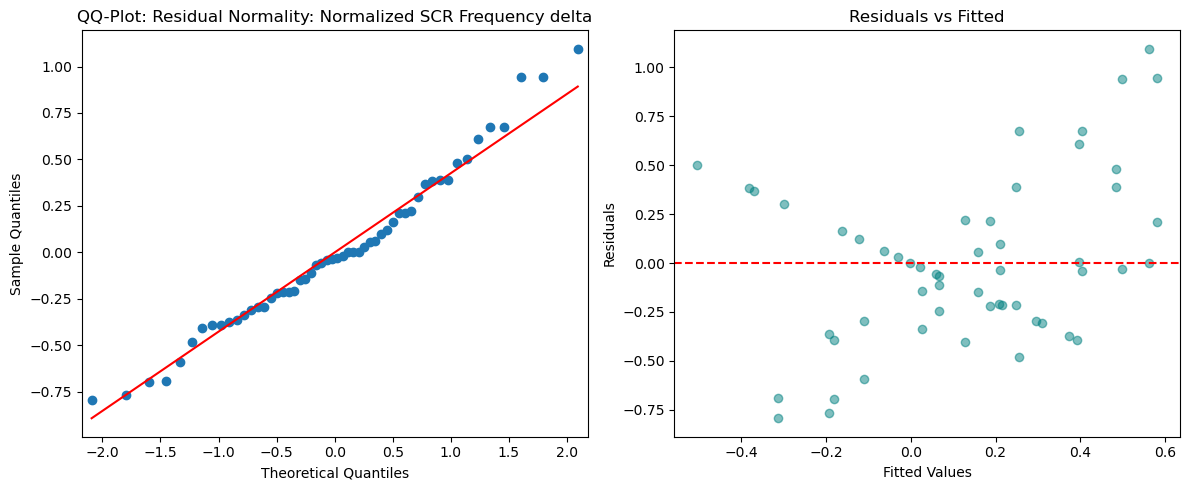

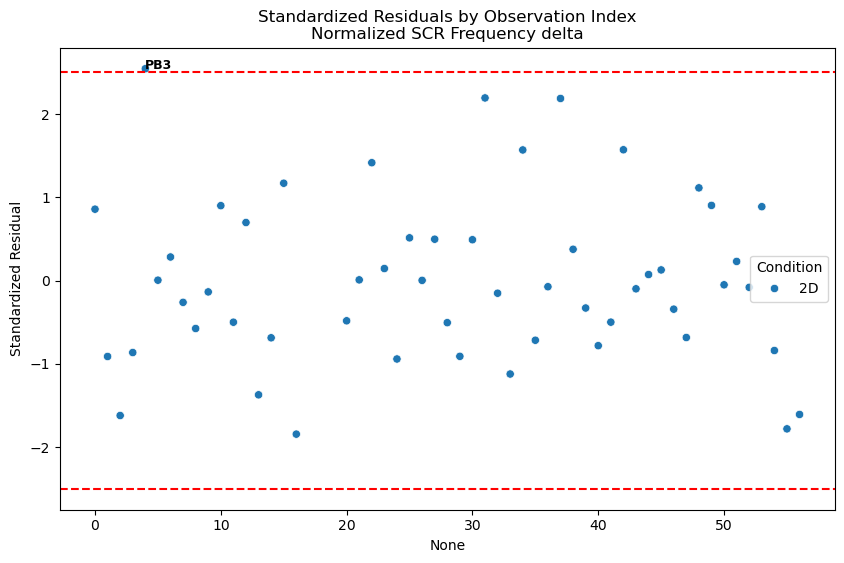

=== Statsmodels Linear Mixed Model EDA_Sympathetic_Delta ~ SegmentType ===
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: EDA_Sympathetic_Delta
No. Observations: 57      Method:             REML                 
No. Groups:       19      Scale:              16176.6574           
Min. group size:  3       Log-Likelihood:     -355.8807            
Max. group size:  3       Converged:          Yes                  
Mean group size:  3.0                                              
-------------------------------------------------------------------
                        Coef.   Std.Err.   z   P>|z|  [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.000   35.507 0.000 1.000 -69.592 69.592
SegmentType[T.Stress]    15.613   35.737 0.437 0.662 -54.429 85.655
Group Var              7777.432   42.082                           

--- FDR (Benjamini-Hochberg) for model EDA_Sympathetic_

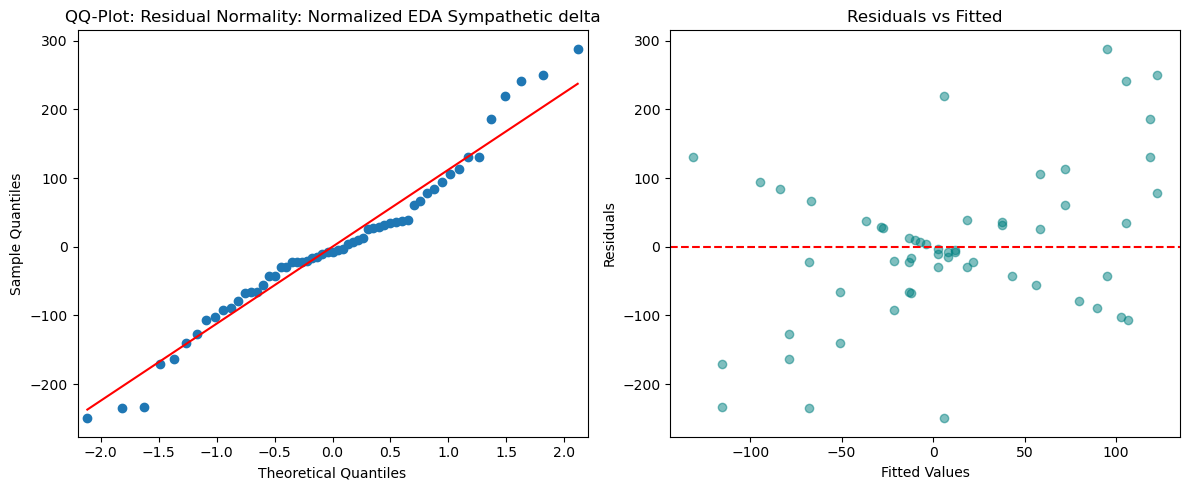

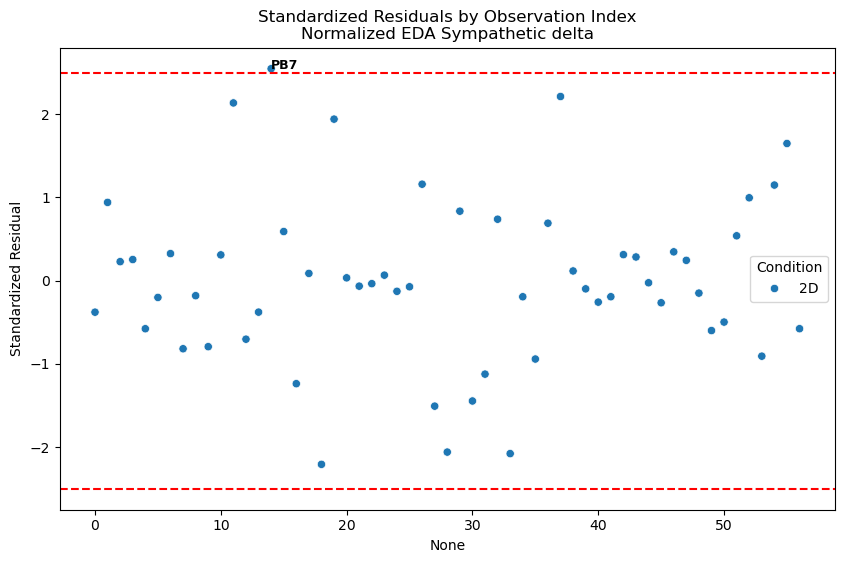

/home/ireguero/.local/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


=== Statsmodels Linear Mixed Model HRV_RMSSD_Delta ~ SegmentType ===
             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  HRV_RMSSD_Delta
No. Observations:  48       Method:              REML           
No. Groups:        16       Scale:               0.0210         
Min. group size:   3        Log-Likelihood:      14.4106        
Max. group size:   3        Converged:           Yes            
Mean group size:   3.0                                          
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.000    0.043 -0.000 1.000 -0.084  0.084
SegmentType[T.Stress]  0.111    0.044  2.510 0.012  0.024  0.198
Group Var              0.009    0.048                           

--- FDR (Benjamini-Hochberg) for model HRV_RMSSD_Delta ~ SegmentType ---
               Predictor  

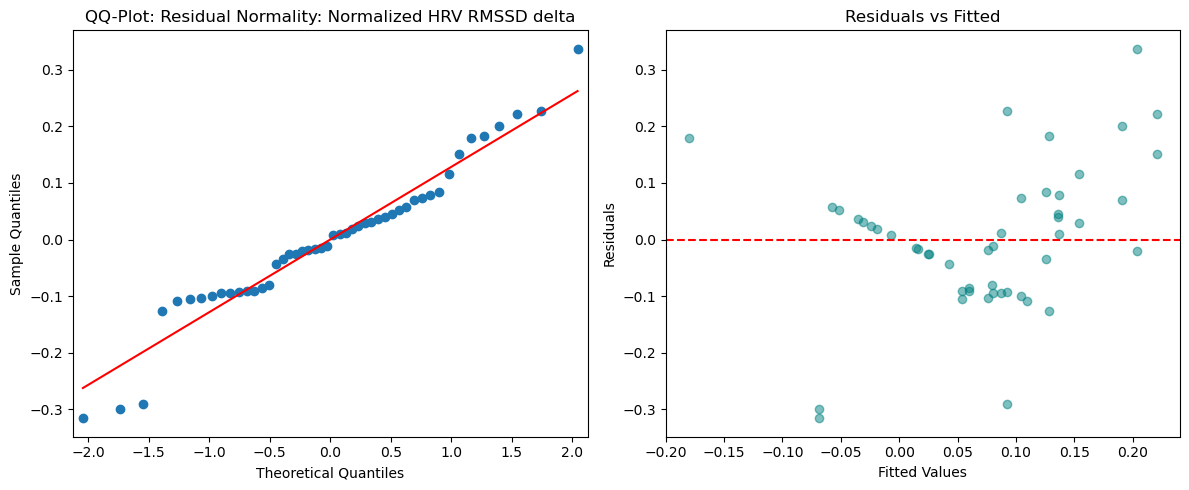

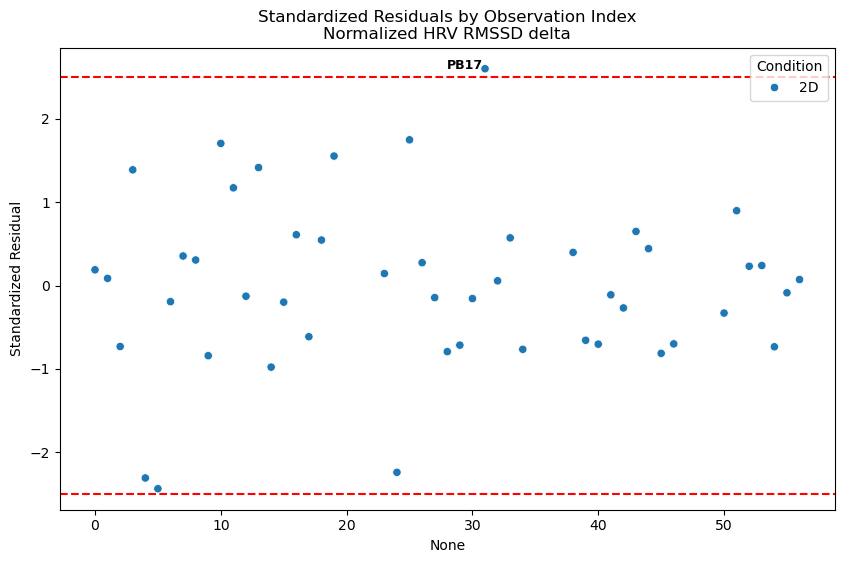

0

In [120]:
main()